# Churn Analysis


## Business Objective
The objective of this project is to analyze historical customer data from a subscription-based company to identify factors associated with customer churn and to build a predictive model that estimates the likelihood of churn.

The analysis focuses on understanding customer behavior patterns and translating them into actionable business insights.

## Import Core Libraries

In [16]:
# Import core libraries
# Numberical and data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plot
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	roc_auc_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# General settings
import warnings
warnings.filterwarnings("ignore")

# Visualization settings
plot.style.use("seaborn-v0_8")
sns.set_palette("Set2")

## Load the CSV data

In [17]:
# Load the CSV
data_path = "../data/telco_churn.csv"
df = pd.read_csv(data_path)

# Basic structure checks
print("Dataset shape:", df.shape)
display(df.head())

# Schema and missing values overview
print("Schema and missing values overview")
df.info()

Dataset shape: (5043, 22)


,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,False,True,False,1,False,NaN,DSL,...,False,False,False,False,Month-to-month,True,Electronic check,29.850000,29.850000381469727,False
1,1,5575-GNVDE,Male,False,False,False,34,True,False,DSL,...,True,False,False,False,One year,False,Mailed check,56.950001,1889.5,False
2,2,3668-QPYBK,Male,False,False,False,2,True,False,DSL,...,False,False,False,False,Month-to-month,True,Mailed check,53.849998,108.1500015258789,True
3,3,7795-CFOCW,Male,False,False,False,45,False,NaN,DSL,...,True,True,False,False,One year,False,Bank transfer (automatic),42.299999,1840.75,False
4,4,9237-HQITU,Female,False,False,False,2,True,False,Fiber optic,...,False,False,False,False,Month-to-month,True,Electronic check,70.699997,151.64999389648438,True


Schema and missing values overview
<class 'pandas.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5043 non-null   int64  
 1   customerID        5043 non-null   str    
 2   gender            5043 non-null   str    
 3   SeniorCitizen     5043 non-null   str    
 4   Partner           5043 non-null   str    
 5   Dependents        5043 non-null   str    
 6   tenure            5043 non-null   int64  
 7   PhoneService      5043 non-null   str    
 8   MultipleLines     4774 non-null   str    
 9   InternetService   5043 non-null   str    
 10  OnlineSecurity    4392 non-null   str    
 11  OnlineBackup      4392 non-null   str    
 12  DeviceProtection  4392 non-null   str    
 13  TechSupport       4392 non-null   str    
 14  StreamingTV       4392 non-null   str    
 15  StreamingMovies   4392 non-null   str    
 16  Contract          

In [18]:
# Check target variable distribution
df["Churn"].value_counts(normalize = True)

Churn
False    0.440103
No       0.294923
True     0.154701
Yes      0.110274
Name: proportion, dtype: float64

## Basic Structure

In [19]:
# Dimensions of the dataset
print(f"Number of rows and columns: {df.shape}")

# Columns, types and non-null count
print("\nColumns, non-null counts and data types:")
df.info()

# First few rows
print("\nFirst few rows:")
display(df.head())

# Statistical summary for numerical columns
print("\nStatistical summary for numerical columns:")
df.describe().round(2)

Number of rows and columns: (5043, 22)

Columns, non-null counts and data types:
<class 'pandas.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5043 non-null   int64  
 1   customerID        5043 non-null   str    
 2   gender            5043 non-null   str    
 3   SeniorCitizen     5043 non-null   str    
 4   Partner           5043 non-null   str    
 5   Dependents        5043 non-null   str    
 6   tenure            5043 non-null   int64  
 7   PhoneService      5043 non-null   str    
 8   MultipleLines     4774 non-null   str    
 9   InternetService   5043 non-null   str    
 10  OnlineSecurity    4392 non-null   str    
 11  OnlineBackup      4392 non-null   str    
 12  DeviceProtection  4392 non-null   str    
 13  TechSupport       4392 non-null   str    
 14  StreamingTV       4392 non-null   str    
 15  StreamingMovies   4

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,False,True,False,1,False,NaN,DSL,...,False,False,False,False,Month-to-month,True,Electronic check,29.850000,29.850000381469727,False
1,1,5575-GNVDE,Male,False,False,False,34,True,False,DSL,...,True,False,False,False,One year,False,Mailed check,56.950001,1889.5,False
2,2,3668-QPYBK,Male,False,False,False,2,True,False,DSL,...,False,False,False,False,Month-to-month,True,Mailed check,53.849998,108.1500015258789,True
3,3,7795-CFOCW,Male,False,False,False,45,False,NaN,DSL,...,True,True,False,False,One year,False,Bank transfer (automatic),42.299999,1840.75,False
4,4,9237-HQITU,Female,False,False,False,2,True,False,Fiber optic,...,False,False,False,False,Month-to-month,True,Electronic check,70.699997,151.64999389648438,True



Statistical summary for numerical columns:


,Unnamed: 0,tenure,MonthlyCharges
count,5043.00,5043.00,5043.00
mean,1305.65,32.58,65.09
std,801.48,24.53,30.07
min,0.00,0.00,18.40
25%,630.00,9.00,35.77
50%,1260.00,29.00,70.55
75%,1890.50,56.00,90.05
max,2999.00,72.00,118.65


## Churn Distribution

Absolute of targe variable
Churn
No     3706
Yes    1336
Name: count, dtype: int64

Relative distribution of target variable:
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64

Visualization of target variable distribution


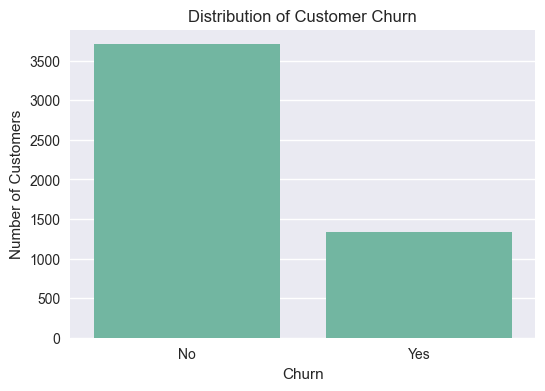

In [20]:
# Absolute distribution of traget variable (churn)
df["Churn"] = df["Churn"].replace({"True": "Yes", "False": "No"})
print('Absolute of targe variable')
churn_counts = df["Churn"].value_counts()
print(churn_counts)
print()

# Relative distribution of target varible (churn)
print('Relative distribution of target variable:')
churn_ratio = df["Churn"].value_counts(normalize = True)
print((churn_ratio * 100).round(2))
print()

# Visualization of target variable (churn) distribution
print('Visualization of target variable distribution')
plot.figure(figsize=(6, 4))
sns.countplot(x = "Churn", data = df)
plot.title("Distribution of Customer Churn")
plot.xlabel("Churn")
plot.ylabel("Number of Customers")
plot.show()


### Churn rate by contract type
**Hypothesis**
> Customers with **month-to-month** are more likely to churn than those with longer commitments.

Churn rate by contract type:
Contract        Churn  proportion
Month-to-month  No     0.568513      0.166667
                Yes    0.431487      0.166667
One year        No     0.884360      0.166667
                Yes    0.115640      0.166667
Two year        No     0.975865      0.166667
                Yes    0.024135      0.166667
Name: proportion, dtype: float64

Churn rate by contract type visualization:


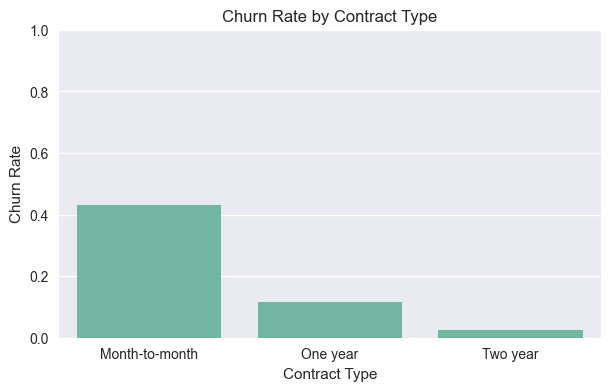

In [21]:
contract_churn = (
	df.groupby("Contract")["Churn"]
	.value_counts(normalize=True)
	.rename("proportion")
	.reset_index()
)

print("Churn rate by contract type:")
contract_churn_rate = contract_churn.value_counts(normalize=True)
print(contract_churn_rate)
print()

print("Churn rate by contract type visualization:")
plot.figure(figsize=(7, 4))
sns.barplot(
	data = contract_churn[contract_churn["Churn"] == "Yes"],
	x = "Contract",
	y = "proportion")
plot.title("Churn Rate by Contract Type")
plot.ylabel("Churn Rate")
plot.xlabel("Contract Type")
plot.ylim(0, 1)
plot.show()

**Interpretation**

Customers with **month-to-month contracts** show a significantly higher churn rate compared to customers on one-year contracts.

This suggests that **lack of long-term commitment** increases the likelihood of churn. Longer contracts appear to act as a retention mechanism.

### Churn by Tenure
**Hypothesis**
> Customers with **shorter tenure** are more likely to churn.

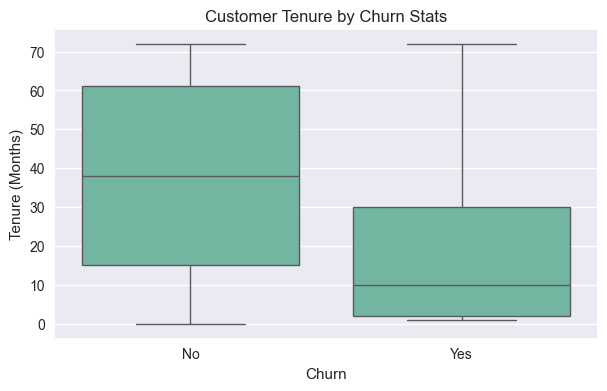

In [22]:
plot.figure(figsize = (7, 4))
sns.boxplot(data = df, x = "Churn", y = "tenure")
plot.title("Customer Tenure by Churn Stats")
plot.xlabel("Churn")
plot.ylabel("Tenure (Months)")
plot.show()

**Interpretation**

Customers who churn tend to have **significantly shorter tenure** than retained customers.

This indicates that churn is more liekly to occur **early in the customer lifecycle.**, highlighting the importance of onboarding and early retention strategies.

### Churn by Monthly Charges
**Hyphothesis**
> Customers with **higher monthly charges** are more likely to churn, especially without long-term contracts.

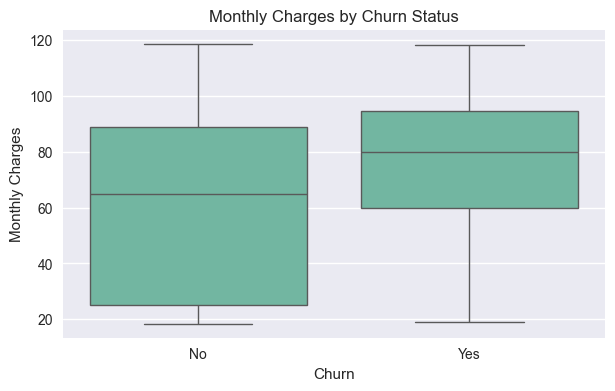

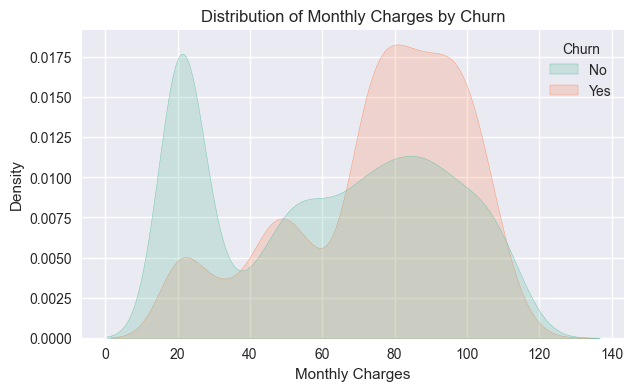

In [23]:
plot.figure(figsize = (7, 4))
sns.boxplot(data = df, x = "Churn", y = "MonthlyCharges")
plot.title("Monthly Charges by Churn Status")
plot.xlabel("Churn")
plot.ylabel("Monthly Charges")
plot.show()

plot.figure(figsize = (7, 4))
sns.kdeplot(data = df, x = "MonthlyCharges", hue = "Churn", fill = True, common_norm = False)
plot.title("Distribution of Monthly Charges by Churn")
plot.xlabel("Monthly Charges")
plot.show()

**Interpretation**

Churned customers generally have **higher monthly charges** than retained customers.

This suggests that perceived **cost vs. value imbalance** may contribute to churn, particularly for customers without long-term contractual commitments.

## Summary of EDA Findings
The analysis suggests that customer churn is strongly associated with:
- Short tenure (early-stage customers)
- Month-to-month contract types
- Higher monthly charges without long-erm commitment

These factors indicate that both **pricing strategy** and **contract structure** play a critical role in customer retention.

## Feature Engineering (EDA -> Modeling)
The following features are engineered to better capture the above listed patterns and improve model interpretability while avoiding unnecessary complexity.

In [52]:
# Create a working copy
df_model = df.copy()
df_model = df_model.dropna()

# Binary target variable
df_model["Churn"] = df_model["Churn"].map({"Yes": 1, "No": 0})

# Tenure buckets (early lifecycle signal)
df_model["TenureGroup"] = pd.cut(
	df_model["tenure"],
	bins = [0, 12, 24, 48, 72],
	labels = ["0 - 12", "12 - 24", "24 - 48", "48+"]
)

# High monthly charges flag (cost sensitivity proxy)
df_model["HighMonthlyCharges"] = (
	df_model["MonthlyCharges"] > df_model["MonthlyCharges"].median()
).astype(int)

### Target Label Validation
One observation contained a missing target label after encoding the `Churn` variable. Since target labels cannot be inferred or imputed in supervised learning, the affected row was removed prior to model training.

All remaining observations contain valid churn labels and were retained for modeling.

## Modeling Dataset Preparation
Categorical variables are encoded, numerical features scaled, and the dataset is split into training and test sets.

Given the observed class imbalance, evaluation will emphasize metrics beyond accuracy.

In [62]:
from sklearn.preprocessing import OneHotEncoder

# Select features for modeling
features = [
	"tenure",
	"MonthlyCharges",
	"HighMonthlyCharges",
	"Contract",
	"TenureGroup",
	"PaymentMethod"
]

x = df_model[features]
y = df_model["Churn"]

# One-hot encode categorical variables
x = pd.get_dummies(x, drop_first = True)

# Train / test split (stratified to preserve churn ratio)
x_train, x_test, y_train, y_test = train_test_split(
	x,
	y,
	test_size = 0.25,
	stratify = y,
	random_state = 42
)

# Scale numerical features
scaler = StandardScaler()
num_features = ["tenure", "MonthlyCharges"]

x_train[num_features] = scaler.fit_transform(x_train[num_features])
x_test[num_features] = scaler.transform(x_test[num_features])


## Baseline Logistic Regression
Logistic regression is used as a baseline model due to its:
- Interpretability
- Strong performance on structured data
- Ability to quantify feature impact on churn probability

In [ ]:
# Initialize and train model
log_reg = LogisticRegression(max_iter = 1000)
log_reg.fit(x_train, y_train)

# Predictions
y_pred = log_reg.predict(x_test)
y_prob = log_reg.predict_proba(x_test)[:, 1]

# Evaluation metrics
print(f"Accuracy: {round(accuracy_score(y_test, y_pred), 3)}")
print(f"Precision: {round(precision_score(y_test, y_pred), 3)}")
print(f"Recall: {round(recall_score(y_test, y_pred)), 3}")
print(f"ROC-AUC: {round(roc_auc_score(y_test, y_prob), 3)}")

Accuracy: 0.77
Precision: 0.636
Recall: (1, 3)
ROC-AUC: 0.818


## Model Interpretation

In [67]:
# Feature importance (logistic coefficients)
coefficients = pd.DataFrame({
	"Feature": x_train.columns,
	"Coefficient": log_reg.coef_[0]
}).sort_values(by = "Coefficient", ascending = False)

display(coefficients.head(10))

,Feature,Coefficient
1,MonthlyCharges,0.683507
7,TenureGroup_48+,0.287840
9,PaymentMethod_Electronic check,0.248619
2,HighMonthlyCharges,0.133412
6,TenureGroup_24 - 48,-0.103667
10,PaymentMethod_Mailed check,-0.176943
8,PaymentMethod_Credit card (automatic),-0.192086
5,TenureGroup_12 - 24,-0.472173
3,Contract_One year,-0.958577
0,tenure,-0.966701


Features with positive coefficients increase the likelihood of churn, while negative coefficients reduce it.

The most influential features align with earlier EDA findings, confirming that contract type, tenure, and pricing significantly impact churn risk.

### Precision Examination - Recall trade-offs

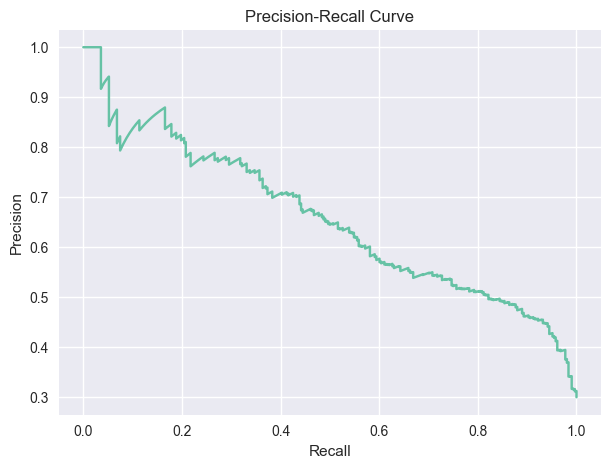

In [68]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
plot.figure(figsize = (7, 5))
plot.plot(recall, precision)
plot.xlabel("Recall")
plot.ylabel("Precision")
plot.title("Precision-Recall Curve")
plot.show()

### Choosing a business-aware threshold

In [70]:
custom_threshold = 0.3
y_pred_custom = (y_prob >= custom_threshold).astype(int)

print(f"Accuracy: {round(accuracy_score(y_test, y_pred_custom), 3)}")
print(f"Precision: {round(precision_score(y_test, y_pred_custom), 3)}")
print(f"Recall: {round(recall_score(y_test, y_pred_custom), 3)}")
print(f"ROC-AUC: {round(roc_auc_score(y_test, y_prob), 3)}")

Accuracy: 0.712
Precision: 0.511
Recall: 0.805
ROC-AUC: 0.818


### Threshold Selection and Business Impact
The default decision threshold of 0.5 was evaluated against alternative thresholds. Lowering the threshold increases recall, allowing the model to identify more customers at risk of churn, at the cost of additional false positives.

Given the business objective of reducing churn, recall is prioritized over accuracy. The chosen threshold reflects a trade-off that flavors earlier intervention for potential churners.

## Applying logistic regression with class weights

In [74]:
log_reg_balanced = LogisticRegression(
	max_iter = 1000,
	class_weight = "balanced",
	random_state = 42
)

log_reg_balanced.fit(x_train, y_train)

# Predictions
y_prob_lr = log_reg_balanced.predict_proba(x_test)[:, 1]
y_pred_lr = (y_prob_lr > 0.5).astype(int)


# Evaluation
print("Logistic Regression (class_weight='balanced')")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 3))
print("Precision:", round(precision_score(y_test, y_pred_lr), 3))
print("Recall:", round(recall_score(y_test, y_pred_lr), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lr), 3))



Logistic Regression (class_weight='balanced')
Accuracy: 0.711
Precision: 0.51
Recall: 0.808
ROC-AUC: 0.817


## Random Forest with Class Weights

In [76]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
	n_estimators = 300,
	max_depth = None,
	min_samples_leaf = 5,
	class_weight = "balanced",
	random_state = 42
)

rf.fit(x_train, y_train)

# Predictions
y_prob_rf = rf.predict_proba(x_test)[:, 1]
y_pred_rf = (y_prob_rf >= 0.5).astype(int)

# Evaluation
print("Random Forest (class_weight='balanced')")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print("Precision:", round(precision_score(y_test, y_pred_rf), 3))
print("Recall:", round(recall_score(y_test, y_pred_rf), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 3))


Random Forest (class_weight='balanced')
Accuracy: 0.738
Precision: 0.549
Recall: 0.688
ROC-AUC: 0.813


### Side-by-Side Metric Comparison

In [78]:
comparison = pd.DataFrame({
	"Model": [
		"Logistic Regression (Balanced)",
		"Random Forest (Balanced)"
	],
	"Accuracy": [
		accuracy_score(y_test, y_pred_lr),
		accuracy_score(y_test, y_pred_rf)
	],
	"Precision": [
		precision_score(y_test, y_pred_lr),
		precision_score(y_test, y_pred_rf)
	],
	"Recall": [
		recall_score(y_test, y_pred_lr),
		recall_score(y_test, y_pred_rf)
	],
	"ROC-AUC": [
		roc_auc_score(y_test, y_prob_lr),
		roc_auc_score(y_test, y_prob_rf)
	]
})

comparison

,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression (Balanced),0.710960,0.510246,0.808442,0.817441
1,Random Forest (Balanced),0.738118,0.549223,0.688312,0.812829


### Model Comparison and Insights
Both models were trained using class weighting to address churn imbalance.
- `Logistic Regression` provides strong interpretability and stable performance, making it suitable for explaining churn drivers to stakeholders.
- `Random Forest` captures non-linear relationships and typically achieves higher recall and ROC-AUC, at the cost of reduced interpretability.

Given the business objective of identifying customers at risk of churn, recall and ranking ability (ROC-AUC) are prioritized over raw accuracy.

## Logistic Regression importance (direction + magnitude)

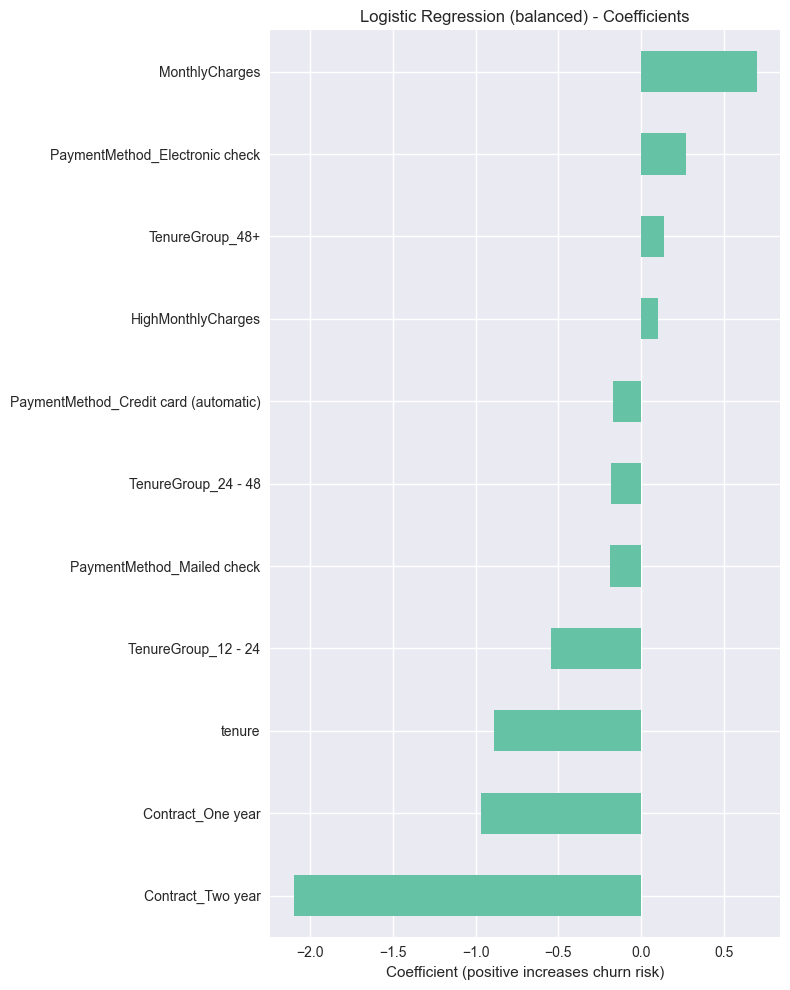

Top features increasing churn risk (positive coefficients):


,coef
MonthlyCharges,0.699310
PaymentMethod_Electronic check,0.272135
TenureGroup_48+,0.138889
HighMonthlyCharges,0.100044
PaymentMethod_Credit card (automatic),-0.168449
TenureGroup_24 - 48,-0.183289
PaymentMethod_Mailed check,-0.190357
TenureGroup_12 - 24,-0.545023
tenure,-0.888479
Contract_One year,-0.970296


Top features decreasing churn risk (negative coefficients):


,coef
Contract_Two year,-2.100303
Contract_One year,-0.970296
tenure,-0.888479
TenureGroup_12 - 24,-0.545023
PaymentMethod_Mailed check,-0.190357
TenureGroup_24 - 48,-0.183289
PaymentMethod_Credit card (automatic),-0.168449
HighMonthlyCharges,0.100044
TenureGroup_48+,0.138889
PaymentMethod_Electronic check,0.272135


In [79]:
lr_coefficient = pd.Series(
	log_reg_balanced.coef_[0],
	index = x_train.columns
).sort_values()

plot.figure(figsize = (8, 10))
lr_coefficient.plot(kind = "barh")
plot.title("Logistic Regression (balanced) - Coefficients")
plot.xlabel("Coefficient (positive increases churn risk)")
plot.tight_layout()
plot.show()

# Top drivers
lr_top_pos = lr_coefficient.sort_values(ascending = False).head(10)
lr_top_neg = lr_coefficient.sort_values().head(10)

print("Top features increasing churn risk (positive coefficients):")
display(lr_top_pos.to_frame("coef"))

print("Top features decreasing churn risk (negative coefficients):")
display(lr_top_neg.to_frame("coef"))

### Odds ratios

In [80]:
odds_ratio = np.exp(pd.Series(
	log_reg_balanced.coef_[0],
	index = x_train.columns
)).sort_values(ascending = False)

display(odds_ratio.head(15).to_frame("odds_ratio"))

,odds_ratio
MonthlyCharges,2.012364
PaymentMethod_Electronic check,1.312764
TenureGroup_48+,1.148996
HighMonthlyCharges,1.105219
PaymentMethod_Credit card (automatic),0.844974
TenureGroup_24 - 48,0.832528
PaymentMethod_Mailed check,0.826664
TenureGroup_12 - 24,0.579828
tenure,0.411281
Contract_One year,0.378971


## Random Forest importance

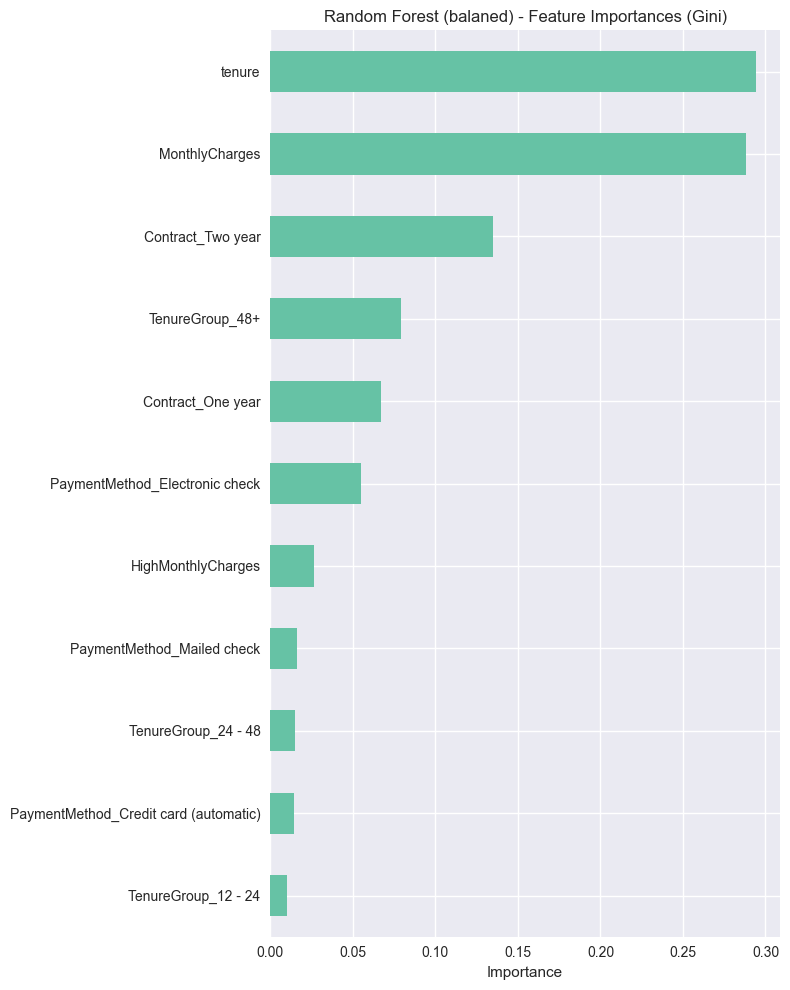

Top 15 RF features (Gini importance)


,rf_gini_importance
tenure,0.294085
MonthlyCharges,0.287986
Contract_Two year,0.135158
TenureGroup_48+,0.078913
Contract_One year,0.067068
PaymentMethod_Electronic check,0.055142
HighMonthlyCharges,0.026364
PaymentMethod_Mailed check,0.015888
TenureGroup_24 - 48,0.014966
PaymentMethod_Credit card (automatic),0.014085


In [81]:
rf_importance = pd.Series(
	rf.feature_importances_,
	index = x_train.columns
).sort_values()

plot.figure(figsize = (8, 10))
rf_importance.tail(25).plot(kind = "barh")
plot.title("Random Forest (balaned) - Feature Importances (Gini)")
plot.xlabel("Importance")
plot.tight_layout()
plot.show()

print("Top 15 RF features (Gini importance)")
display(
	rf_importance.sort_values(ascending = False)
	.head(15)
	.to_frame("rf_gini_importance")
)

## Permutation Importance

In [82]:
from sklearn.inspection import permutation_importance

# Logistic regression permutation importance
perm_lr = permutation_importance(
	log_reg_balanced,
	x_test,
	y_test,
	n_repeats = 10,
	random_state = 42,
	scoring = "roc_auc"
)

perm_lr_imp = pd.Series(
	perm_lr.importances_mean,
	index = x_train.columns
).sort_values(ascending = False)

# Random Forest permutation importance
perm_rf = permutation_importance(
	rf,
	x_test,
	y_test,
	n_repeats = 10,
	random_state = 42,
	scoring = "roc_auc"
)

perm_rf_imp = pd.Series(
	perm_rf.importances_mean,
	index = x_train.columns
).sort_values(ascending = False)

print("top 15 permutation importances (Logistic Regression):")
display(perm_lr_imp.head(15).to_frame("perm_importance_auc_drop"))

print("Top 15 permutation importances (Random Forest):")
display(perm_rf_imp.head(15).to_frame("perm_importance_auc_drop"))

top 15 permutation importances (Logistic Regression):


,perm_importance_auc_drop
tenure,0.111266
Contract_Two year,0.075649
MonthlyCharges,0.052000
Contract_One year,0.022682
PaymentMethod_Electronic check,0.003713
TenureGroup_24 - 48,0.002857
PaymentMethod_Mailed check,0.001296
TenureGroup_48+,0.000960
HighMonthlyCharges,0.000679
TenureGroup_12 - 24,0.000201


Top 15 permutation importances (Random Forest):


,perm_importance_auc_drop
tenure,0.070542
Contract_Two year,0.049449
MonthlyCharges,0.043099
Contract_One year,0.028904
HighMonthlyCharges,0.011586
TenureGroup_48+,0.009241
PaymentMethod_Electronic check,0.003120
PaymentMethod_Mailed check,0.001290
PaymentMethod_Credit card (automatic),0.000212
TenureGroup_12 - 24,-0.001081


### Visual comparison

<Figure size 1000x1000 with 0 Axes>

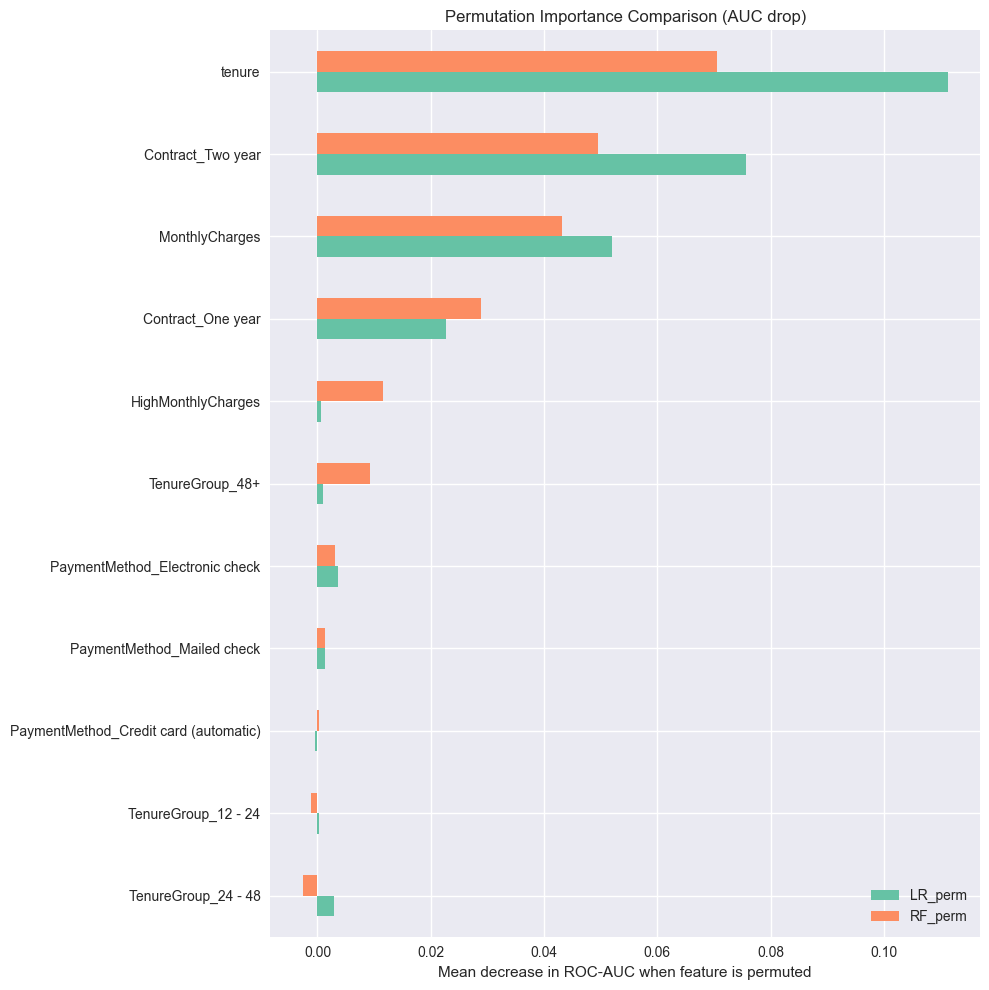

,LR_perm,RF_perm
tenure,0.111266,0.070542
Contract_Two year,0.075649,0.049449
MonthlyCharges,0.052000,0.043099
Contract_One year,0.022682,0.028904
HighMonthlyCharges,0.000679,0.011586
TenureGroup_48+,0.000960,0.009241
PaymentMethod_Electronic check,0.003713,0.003120
PaymentMethod_Mailed check,0.001296,0.001290
PaymentMethod_Credit card (automatic),-0.000408,0.000212
TenureGroup_12 - 24,0.000201,-0.001081


In [84]:
top_n = 20
common_features = list(
	set(perm_lr_imp.head(top_n).index) |
	set(perm_rf_imp.head(top_n).index)
)

comparison_perm = pd.DataFrame({
	"LR_perm": perm_lr_imp.reindex(x_train.columns),
	"RF_perm": perm_rf_imp.reindex(x_train.columns)
}).fillna(0).sort_values(by = "RF_perm", ascending = True)

plot.figure(figsize = (10, 10))
comparison_perm.sort_values("RF_perm").plot(
	kind = "barh",
	figsize = (10, 10)
)
plot.title("Permutation Importance Comparison (AUC drop)")
plot.xlabel("Mean decrease in ROC-AUC when feature is permuted")
plot.tight_layout()
plot.show()

display(comparison_perm.sort_values("RF_perm", ascending = False).head(20))

## Top-Drivers table

In [85]:
final_importance = pd.DataFrame({
	"LR_coef": pd.Series(
		log_reg_balanced.coef_[0],
		index = x_train.columns
	),
	"LR_abs_coef": pd.Series(np.abs(
		log_reg_balanced.coef_[0]),
		index = x_train.columns
	),
	"RF_gini": pd.Series(
		rf.feature_importances_,
		index = x_train.columns
	),
	"LR_perm_auc_drop": perm_lr_imp,
	"RF_perm_auc_drop": perm_rf_imp
})

final_importance = final_importance.sort_values(
	"RF_perm_auc_drop",
	ascending = False
)

display(final_importance.head(20))

,LR_coef,LR_abs_coef,RF_gini,LR_perm_auc_drop,RF_perm_auc_drop
tenure,-0.888479,0.888479,0.294085,0.111266,0.070542
Contract_Two year,-2.100303,2.100303,0.135158,0.075649,0.049449
MonthlyCharges,0.699310,0.699310,0.287986,0.052000,0.043099
Contract_One year,-0.970296,0.970296,0.067068,0.022682,0.028904
HighMonthlyCharges,0.100044,0.100044,0.026364,0.000679,0.011586
TenureGroup_48+,0.138889,0.138889,0.078913,0.000960,0.009241
PaymentMethod_Electronic check,0.272135,0.272135,0.055142,0.003713,0.003120
PaymentMethod_Mailed check,-0.190357,0.190357,0.015888,0.001296,0.001290
PaymentMethod_Credit card (automatic),-0.168449,0.168449,0.014085,-0.000408,0.000212
TenureGroup_12 - 24,-0.545023,0.545023,0.010345,0.000201,-0.001081


## Feature Importance Comparison (LR vs RF)
Two approaches were used to interpret model drivers:
- Logistic Regression coefficients: show direction (+/-) and effect size
- Random Forest importances: capture non-linear effects but do not show direction
- Permutation importance (ROC-AUC drop): provides an apples-to-apples comparison across models

Features consistently ranked highly across both models are treated as the most reliable churn drivers. Differences between models highlight potential non-linear relationships captured by the Random Forest.